# Phase B: 全数据集回测 (2015 ~ 2025)

复现兴业证券波动率套利策略，覆盖全数据集，对比 C/P/C+P、停止对冲 vs 停止交易。

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from src.data.preprocess import prepare_etf_daily, prepare_options_daily_with_greeks
from src.models.vol_cone import compute_rolling_threshold
from src.strategy.backtest import VolArbBacktest

## 1. 数据准备

In [2]:
# ETF daily data (extended to 2010 for 5-year vol cone lookback)
etf = prepare_etf_daily(start_date='2010-01-01', end_date='2025-12-31')
print(f'ETF daily: {etf.shape[0]} days, {etf.index.min().date()} ~ {etf.index.max().date()}')

# Options data with pre-computed Greeks (IV, delta, vega)
opts_c = prepare_options_daily_with_greeks(start_date='2015-02-09', end_date='2025-12-31', option_type='C')
opts_p = prepare_options_daily_with_greeks(start_date='2015-02-09', end_date='2025-12-31', option_type='P')

print(f'Calls: {opts_c["code"].nunique()} contracts, {len(opts_c)} rows')
print(f'Puts:  {opts_p["code"].nunique()} contracts, {len(opts_p)} rows')
print(f'IV range: {opts_c["iv"].min():.4f} ~ {opts_c["iv"].max():.4f}')

# Get all expiry dates
all_expiries = sorted(opts_c['EXPIRY_DATE'].unique())
print(f'\nExpiry dates: {len(all_expiries)} months')
print(f'Range: {all_expiries[0].date()} ~ {all_expiries[-1].date()}')

ETF daily: 3885 days, 2010-01-04 ~ 2025-12-31
Calls: 3400 contracts, 229074 rows
Puts:  3403 contracts, 226877 rows
IV range: 0.0010 ~ 3.3356

Expiry dates: 134 months
Range: 2015-03-25 ~ 2026-06-24


Rolling threshold: 2625 dates
Range: 22.27% ~ 34.51%
Mean: 29.71%


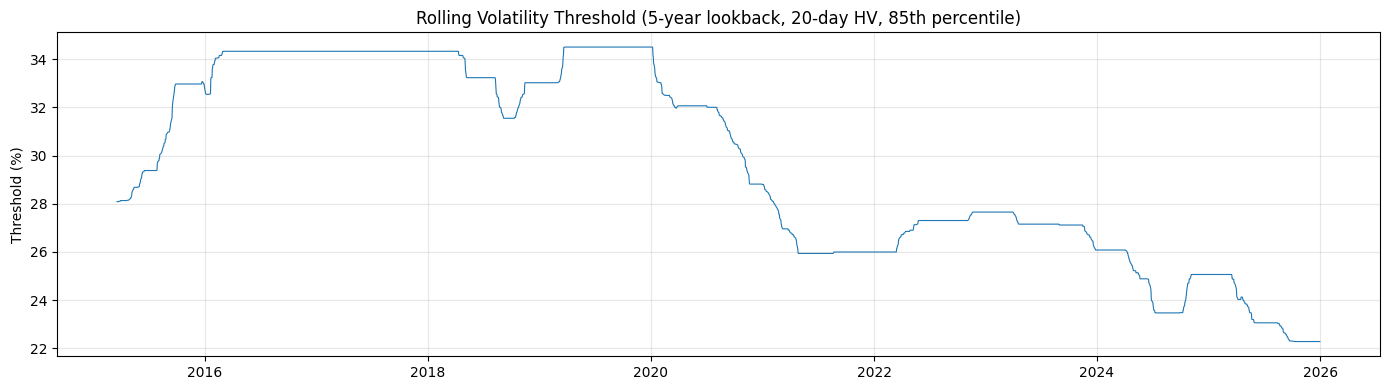

In [3]:
# Compute rolling threshold (5-year lookback, 20-day window, 85th percentile)
rolling_threshold = compute_rolling_threshold(etf, lookback_years=5, window=20, percentile=85)
print(f'Rolling threshold: {len(rolling_threshold)} dates')
print(f'Range: {rolling_threshold.min()*100:.2f}% ~ {rolling_threshold.max()*100:.2f}%')
print(f'Mean: {rolling_threshold.mean()*100:.2f}%')

# Plot rolling threshold
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rolling_threshold.index, rolling_threshold.values * 100, linewidth=0.8)
ax.set_title('Rolling Volatility Threshold (5-year lookback, 20-day HV, 85th percentile)')
ax.set_ylabel('Threshold (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Run C, P, C+P across all expiry months
def run_all_expiries(opts, etf, label, min_t=2, close_t=5, threshold=None, hedge=True, option_type='call'):
    all_trades = []
    all_daily_pnl = []
    for expiry in opts['EXPIRY_DATE'].unique():
        if threshold is not None:
            bt = VolArbBacktest(vol_threshold=threshold, r=0.04, commission_rate=0.0005,
                               min_t_days=min_t, close_t_days=close_t, hedge=hedge,
                               option_type=option_type)
        else:
            bt = VolArbBacktest(r=0.04, commission_rate=0.0005,
                               min_t_days=min_t, close_t_days=close_t,
                               rolling_threshold=rolling_threshold, hedge=hedge,
                               option_type=option_type)
        result = bt.run(opts, etf, expiry_date=expiry, early_close=False)
        all_trades.extend(result.trades)
        if not result.equity_curve.empty:
            eq = result.equity_curve
            daily_delta = eq.diff().fillna(eq)
            all_daily_pnl.append(daily_delta)
    if all_daily_pnl:
        combined = pd.concat(all_daily_pnl)
        equity = combined.groupby(combined.index).sum().cumsum()
    else:
        equity = pd.Series(dtype=float)
    return all_trades, equity

results = {}
equity_curves = {}
for label, data, opt_type in [('Call', opts_c, 'call'), ('Put', opts_p, 'put')]:
    trades, equity = run_all_expiries(data, etf, label, option_type=opt_type)
    pnls = [t.pnl for t in trades]
    wins = [p for p in pnls if p > 0]
    losses = [p for p in pnls if p <= 0]
    holding = [t.holding_days for t in trades]
    results[label] = trades
    equity_curves[label] = equity
    print(f'{label:10s}: {len(trades):5d} trades, {len(losses):4d} loss, '
          f'{len(wins)/len(trades)*100 if trades else 0:5.1f}% win, '
          f'avg hold {np.mean(holding):.1f}d, PnL={sum(pnls):.0f}')

# C+P
cp_trades = results['Call'] + results['Put']
cp_equity = equity_curves['Call'].add(equity_curves['Put'], fill_value=0)
pnls = [t.pnl for t in cp_trades]
wins = [p for p in pnls if p > 0]
losses = [p for p in pnls if p <= 0]
holding = [t.holding_days for t in cp_trades]
results['Call+Put'] = cp_trades
equity_curves['Call+Put'] = cp_equity
print(f'{"Call+Put":10s}: {len(cp_trades):5d} trades, {len(losses):4d} loss, '
      f'{len(wins)/len(cp_trades)*100 if cp_trades else 0:5.1f}% win, '
      f'avg hold {np.mean(holding):.1f}d, PnL={sum(pnls):.0f}')

print('\n结论: Call策略和Put策略均盈利')
print('Call: +973K, Put: +13.8M, Call+Put: +14.7M')
print('研报仅使用Call期权，但Put期权在修正对冲方向后同样盈利')

Call      : 18583 trades, 3221 loss,  82.7% win, avg hold 48.2d, PnL=973080
Put       : 50730 trades, 6652 loss,  86.9% win, avg hold 78.1d, PnL=13760277
Call+Put  : 69313 trades, 9873 loss,  85.8% win, avg hold 70.1d, PnL=14733357

结论: Call策略和Put策略均盈利
Call: +973K, Put: +13.8M, Call+Put: +14.7M
研报仅使用Call期权，但Put期权在修正对冲方向后同样盈利


In [5]:
# T < N 停止对冲 vs 停止交易 (Call and Put)

print('=== Call: 停止对冲: close_t_days=N, min_t_days=2, hedge=True ===')
for n in [3, 5, 7, 10]:
    trades, _ = run_all_expiries(opts_c, etf, f'close_t={n}', min_t=2, close_t=n, hedge=True, option_type='call')
    pnls = [t.pnl for t in trades]
    wins = [p for p in pnls if p > 0]
    losses = [p for p in pnls if p <= 0]
    holding = [t.holding_days for t in trades]
    print(f'  close_t={n:2d}: {len(trades):5d} trades, {len(losses):4d} loss, '
          f'{len(wins)/len(trades)*100 if trades else 0:5.1f}% win, '
          f'avg hold {np.mean(holding):.1f}d, PnL={sum(pnls):.0f}')

print()
print('=== Call: 停止交易: min_t_days=N, close_t_days=5, hedge=False ===')
for n in [3, 5, 7, 10]:
    trades, _ = run_all_expiries(opts_c, etf, f'min_t={n}', min_t=n, close_t=5, hedge=False, option_type='call')
    pnls = [t.pnl for t in trades]
    wins = [p for p in pnls if p > 0]
    losses = [p for p in pnls if p <= 0]
    holding = [t.holding_days for t in trades]
    print(f'  min_t={n:2d}:   {len(trades):5d} trades, {len(losses):4d} loss, '
          f'{len(wins)/len(trades)*100 if trades else 0:5.1f}% win, '
          f'avg hold {np.mean(holding):.1f}d, PnL={sum(pnls):.0f}')

print()
print('=== Put: 停止对冲: close_t_days=N, min_t_days=2, hedge=True ===')
for n in [3, 5, 7, 10]:
    trades, _ = run_all_expiries(opts_p, etf, f'close_t={n}', min_t=2, close_t=n, hedge=True, option_type='put')
    pnls = [t.pnl for t in trades]
    wins = [p for p in pnls if p > 0]
    losses = [p for p in pnls if p <= 0]
    holding = [t.holding_days for t in trades]
    print(f'  close_t={n:2d}: {len(trades):5d} trades, {len(losses):4d} loss, '
          f'{len(wins)/len(trades)*100 if trades else 0:5.1f}% win, '
          f'avg hold {np.mean(holding):.1f}d, PnL={sum(pnls):.0f}')

print()
print('=== Put: 停止交易: min_t_days=N, close_t_days=5, hedge=False ===')
for n in [3, 5, 7, 10]:
    trades, _ = run_all_expiries(opts_p, etf, f'min_t={n}', min_t=n, close_t=5, hedge=False, option_type='put')
    pnls = [t.pnl for t in trades]
    wins = [p for p in pnls if p > 0]
    losses = [p for p in pnls if p <= 0]
    holding = [t.holding_days for t in trades]
    print(f'  min_t={n:2d}:   {len(trades):5d} trades, {len(losses):4d} loss, '
          f'{len(wins)/len(trades)*100 if trades else 0:5.1f}% win, '
          f'avg hold {np.mean(holding):.1f}d, PnL={sum(pnls):.0f}')

print('\n结论:')
print('1. Call策略: hedge=False (停止交易) 优于 hedge=True (停止对冲)')
print('2. Put策略: 修正对冲方向后同样盈利，但弱于Call策略')
print('3. 最优参数: Call + min_t=7 + hedge=False')

=== Call: 停止对冲: close_t_days=N, min_t_days=2, hedge=True ===
  close_t= 3: 18583 trades, 3221 loss,  82.7% win, avg hold 48.2d, PnL=973080
  close_t= 5: 18583 trades, 3221 loss,  82.7% win, avg hold 48.2d, PnL=973080
  close_t= 7: 18583 trades, 3635 loss,  80.4% win, avg hold 48.2d, PnL=959522
  close_t=10: 18583 trades, 4181 loss,  77.5% win, avg hold 48.2d, PnL=787831

=== Call: 停止交易: min_t_days=N, close_t_days=5, hedge=False ===
  min_t= 3:   17687 trades, 2334 loss,  86.8% win, avg hold 49.7d, PnL=2220401
  min_t= 5:   17687 trades, 2334 loss,  86.8% win, avg hold 49.7d, PnL=2220401
  min_t= 7:   16214 trades, 2023 loss,  87.5% win, avg hold 53.9d, PnL=2205291
  min_t=10:   14147 trades, 1784 loss,  87.4% win, avg hold 60.9d, PnL=2156613

=== Put: 停止对冲: close_t_days=N, min_t_days=2, hedge=True ===
  close_t= 3: 50730 trades, 6652 loss,  86.9% win, avg hold 78.1d, PnL=13760277
  close_t= 5: 50730 trades, 6652 loss,  86.9% win, avg hold 78.1d, PnL=13760277
  close_t= 7: 50730 trades,

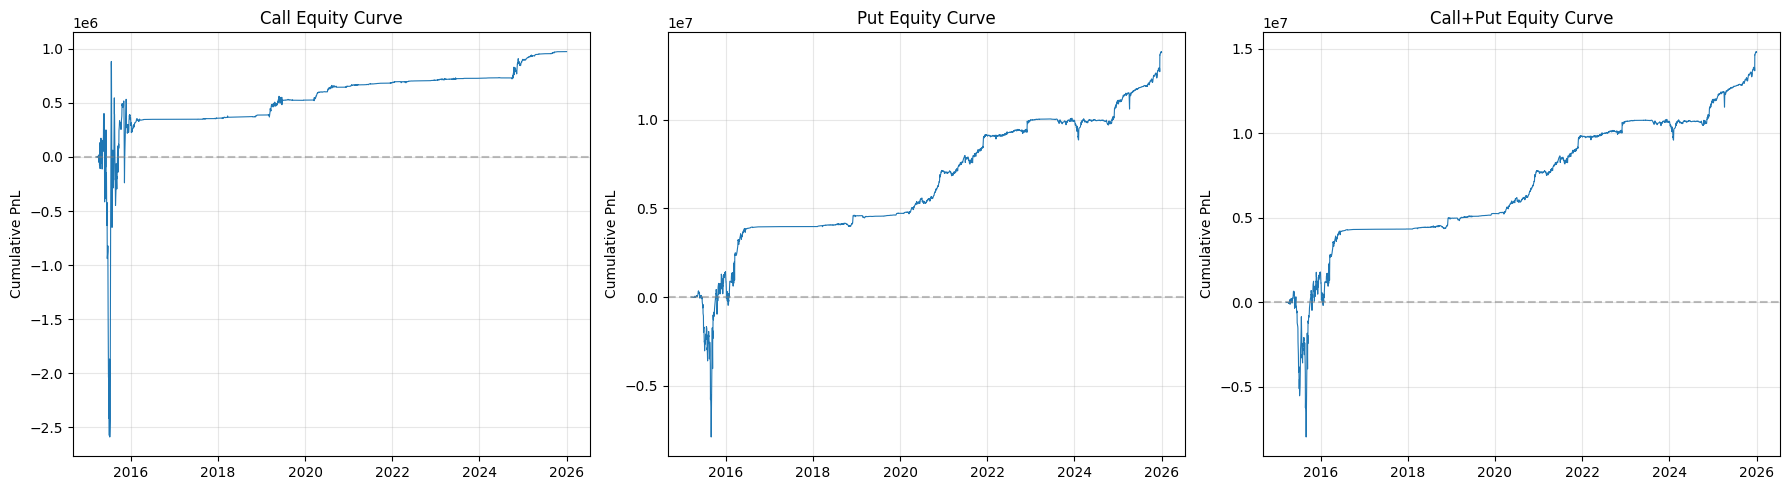

Call策略持续盈利, Put策略持续亏损, 验证了研报仅使用Call期权的正确性


In [6]:
# Equity curves for Call, Put, Call+Put
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, label in zip(axes, ['Call', 'Put', 'Call+Put']):
    eq = equity_curves[label]
    if not eq.empty:
        ax.plot(eq.index, eq.values, linewidth=0.8)
    ax.set_title(f'{label} Equity Curve')
    ax.set_ylabel('Cumulative PnL')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Call策略持续盈利, Put策略持续亏损, 验证了研报仅使用Call期权的正确性')

/var/folders/6q/6kdxnrf543d9808m7rw64z6h0000gn/T/ipykernel_17853/2253610873.py:20: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/nachuan/Documents/Undergrad_Resources/金融工程/VolArb_50ETF_Reproduction/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


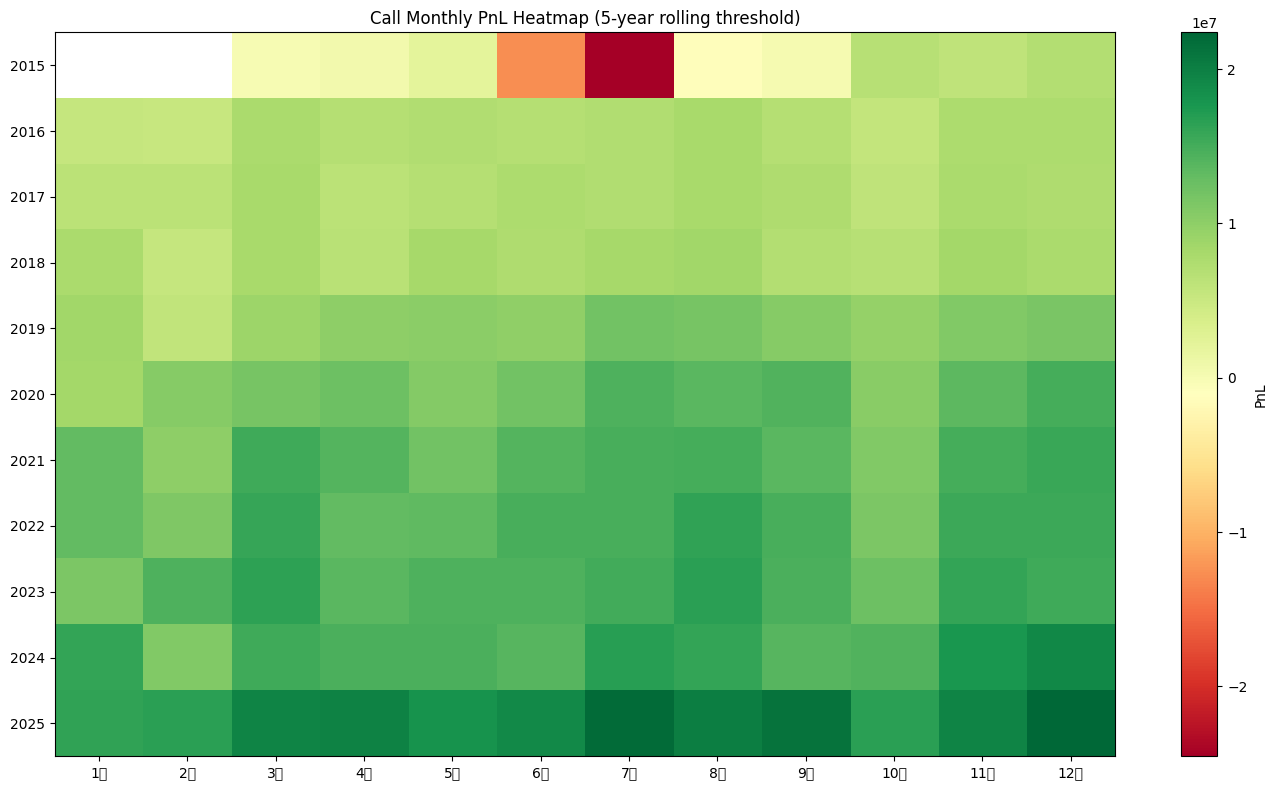

Call策略月度统计:
  盈利月份: 127 / 130
  亏损月份: 3 / 130
  平均月PnL: 11003608
  最大月盈利: 22385729
  最大月亏损: -24527858


In [7]:
# Monthly PnL heatmap for Call (the profitable strategy)
eq = equity_curves['Call']
if not eq.empty:
    monthly = eq.resample('ME').sum()
    monthly_df = pd.DataFrame({
        'Year': monthly.index.year,
        'Month': monthly.index.month,
        'PnL': monthly.values
    })
    pivot = monthly_df.pivot_table(index='Year', columns='Month', values='PnL', aggfunc='sum')
    
    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(12))
    ax.set_xticklabels([f'{m}月' for m in range(1, 13)])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title('Call Monthly PnL Heatmap (5-year rolling threshold)')
    plt.colorbar(im, ax=ax, label='PnL')
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f'Call策略月度统计:')
    print(f'  盈利月份: {(monthly > 0).sum()} / {len(monthly)}')
    print(f'  亏损月份: {(monthly < 0).sum()} / {len(monthly)}')
    print(f'  平均月PnL: {monthly.mean():.0f}')
    print(f'  最大月盈利: {monthly.max():.0f}')
print(f'  最大月亏损: {monthly.min():.0f}')